# Trabajo Práctico 2 — Tecnología Digital VI

**Integrantes:** Facundo Arechaga, Franco Bergman

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")

### 1. Introducción al problema y Análisis Exploratorio

- i) El conjunto de datos utilizado en este trabajo práctico contiene información sobre distintas canciones obtenida a partir de métricas acústicas de Spotify. Cada fila representa una canción y cada columna contiene distintas características musicales que describen aspectos como su energía, ritmo, popularidad o nivel de instrumentalidad.

El objetivo del problema es utilizar estas características para predecir a qué género musical pertenece cada canción.

Hay varias variables:

- **Id:** Identificador único de cada canción.

- **popularity:** Nivel de popularidad de la canción.

- **duration_ms:** Duración de la canción medida en milisegundos.

- **explicit:** Indica si la canción contiene contenido explícito.

- **danceability:** Representa qué tan adecuada es una canción para bailar, teniendo en cuenta elementos como el tempo, la estabilidad del ritmo y la regularidad general.

- **energy:** Mide la intensidad y actividad percibida de una canción. Valores altos suelen corresponder a canciones más rápidas, fuertes o intensas.

- **key:** Representa la tonalidad musical principal de la canción.

- **loudness:** Volumen general de la canción, medido en decibeles.

- **mode:** Indica si la canción está principalmente en modo mayor o menor.

- **speechiness:** Mide la presencia de palabras habladas dentro de la canción.

- **acousticness:** Estima qué tan acústica es una canción. Valores altos indican una mayor presencia de instrumentos o sonidos acústicos.

- **instrumentalness:** Indica la probabilidad de que una canción sea principalmente instrumental y tenga poca o ninguna presencia vocal.

- **liveness:** Mide la probabilidad de que la grabación haya sido realizada en vivo.

- **valence:** Representa el carácter emocional de la canción. Valores altos suelen asociarse con canciones más positivas o alegres.

- **tempo:** Indica la velocidad de la canción, generalmente medida en beats por minuto.

- **time_signature:** Indica el compás de la canción, es decir, cuántos tiempos o pulsos hay en cada compás.

La variable objetivo es **Expected**, que indica el género musical al que pertenece cada canción. En este caso, se trata de un problema de **clasificación multiclase**, ya que existen varios géneros posibles: jazz, electronic, hip-hop, acoustic, rock y classical.

El problema consiste en desarrollar un modelo de Machine Learning capaz de identificar correctamente el género de una canción utilizando únicamente sus características acústicas.

Además, buscamos analizar qué variables permiten diferenciar mejor los distintos géneros y comparar distintos modelos de clasificación.

Desde el punto de vista de negocio, este tipo de modelo podría ser útil para una plataforma como Spotify para clasificar automáticamente canciones nuevas, organizar catálogos y mejorar sistemas de recomendación.

En este contexto, no solo interesa acertar exactamente el género principal, sino también que el género correcto aparezca entre las principales predicciones del modelo. Por eso, además de utilizar **F1-Macro**, también se analizará la métrica **MAP@3**, que evalúa si el género correcto aparece dentro de las tres predicciones principales del modelo.

In [3]:
df.head() # Muestra las primeras 5 filas del DataFrame

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Expected,Id
0,0,143733,False,0.439,0.196,0,-16.093,1,0.0601,0.88000,0.0000,0.0513,0.525,129.581,4,jazz,4271
1,0,261562,False,0.627,0.876,11,-4.391,0,0.0324,0.01590,0.0000,0.0665,0.418,111.950,4,electronic,2078
2,63,190131,False,0.767,0.869,2,-3.381,0,0.0908,0.14000,0.0000,0.2210,0.751,98.208,4,hip-hop,4921
3,48,201440,False,0.374,0.183,9,-13.225,1,0.0281,0.89700,0.0387,0.1090,0.134,82.042,4,acoustic,4206
4,0,168552,True,0.423,0.721,0,-8.070,1,0.1650,0.00792,0.0000,0.3800,0.382,161.926,4,rock,2423


In [4]:
df.shape # Muestra el número de filas y columnas del DataFrame

(4200, 17)

In [5]:
df.info() # Muestra información sobre el DataFrame, incluyendo el tipo de datos de cada columna y la cantidad de valores no nulos

<class 'pandas.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   popularity        4200 non-null   int64  
 1   duration_ms       4200 non-null   int64  
 2   explicit          4200 non-null   bool   
 3   danceability      4200 non-null   float64
 4   energy            4200 non-null   float64
 5   key               4200 non-null   int64  
 6   loudness          4200 non-null   float64
 7   mode              4200 non-null   int64  
 8   speechiness       4200 non-null   float64
 9   acousticness      4200 non-null   float64
 10  instrumentalness  4200 non-null   float64
 11  liveness          4200 non-null   float64
 12  valence           4200 non-null   float64
 13  tempo             4200 non-null   float64
 14  time_signature    4200 non-null   int64  
 15  Expected          4200 non-null   str    
 16  Id                4200 non-null   int64  
dtypes: boo

In [6]:
df.isnull().sum() # Muestra la cantidad de valores nulos en cada columna del DataFrame

popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
Expected            0
Id                  0
dtype: int64

In [7]:
df.describe() # Muestra estadísticas descriptivas de las columnas numéricas del DataFrame, como la media, desviación estándar, valores mínimo y máximo, y percentiles.

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Id
count,4200.000000,4.200000e+03,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.00000
mean,28.379524,2.166272e+05,0.560357,0.505509,5.233571,-10.190675,0.667143,0.068335,0.462576,0.170266,0.175381,0.459639,117.591598,3.874286,2991.09119
std,27.610356,1.090433e+05,0.173039,0.271108,3.589029,6.446329,0.471292,0.071875,0.375937,0.326240,0.136275,0.248920,30.394517,0.481529,1729.94323
min,0.000000,1.745300e+04,0.000000,0.000756,0.000000,-41.531000,0.000000,0.000000,0.000006,0.000000,0.017900,0.000000,0.000000,0.000000,2.00000
25%,0.000000,1.659868e+05,0.443000,0.278000,2.000000,-12.472000,0.000000,0.034100,0.075400,0.000000,0.097500,0.250000,93.931000,4.000000,1490.75000
50%,28.000000,2.038800e+05,0.571000,0.529000,5.000000,-8.187000,1.000000,0.043200,0.417000,0.000052,0.121000,0.445500,116.098000,4.000000,2999.00000
75%,55.000000,2.470400e+05,0.689000,0.737000,8.000000,-5.773250,1.000000,0.065100,0.853000,0.075275,0.209000,0.650000,136.470000,4.000000,4481.25000
max,92.000000,2.646866e+06,0.959000,0.997000,11.000000,-0.927000,1.000000,0.905000,0.996000,0.978000,0.962000,0.980000,214.016000,5.000000,5999.00000


In [8]:
df.nunique() # Muestra la cantidad de valores únicos en cada columna del DataFrame


popularity            93
duration_ms         3147
explicit               2
danceability         737
energy              1129
key                   12
loudness            3005
mode                   2
speechiness          849
acousticness        1508
instrumentalness    1603
liveness             877
valence             1036
tempo               3172
time_signature         5
Expected               6
Id                  4200
dtype: int64

In [9]:
df.dtypes # Muestra los tipos de datos de cada columna del DataFrame

popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
Expected                str
Id                    int64
dtype: object

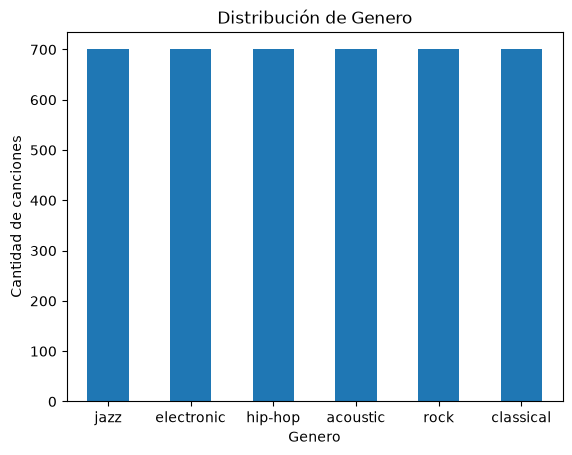

In [10]:
# Distribución de géneros
df["Expected"].value_counts().plot(kind="bar")

plt.title("Distribución de Genero")
plt.xlabel("Genero")
plt.ylabel("Cantidad de canciones")
plt.xticks(rotation=0)
plt.show()


El conjunto de datos se encuentra perfectamente balanceado, ya que los seis géneros contienen la misma cantidad de canciones. Esto es positivo para el entrenamiento, porque evita que el modelo tienda a favorecer a una clase por tener más ejemplos que las demás.

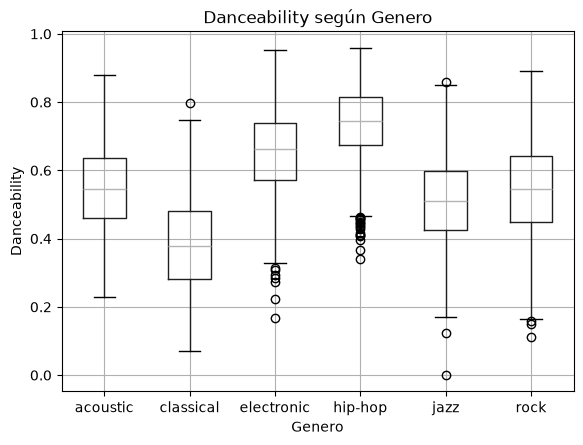

In [11]:
# Boxplot de Danceability según Genero
df.boxplot(
    column="danceability",
    by="Expected"
)

plt.title("Danceability según Genero")
plt.suptitle("")
plt.xlabel("Genero")
plt.ylabel("Danceability")
plt.show()

La variable `danceability` muestra diferencias claras entre algunos géneros. `hip-hop` presenta los valores más altos, seguido por `electronic`, mientras que `classical` tiene los valores más bajos. Sin embargo, algunos géneros como `acoustic`, `jazz` y `rock` presentan bastante superposición.

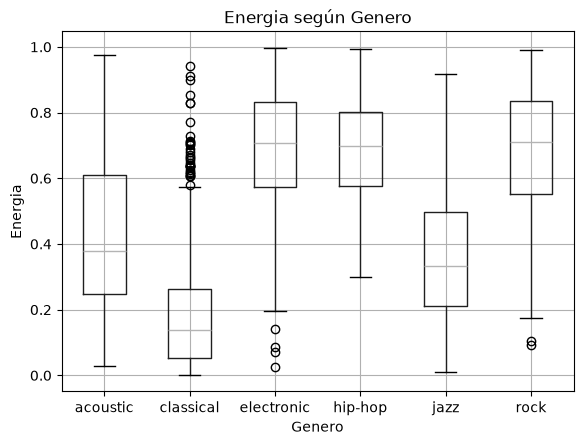

In [12]:
# Boxplot de Energy según Genero
df.boxplot(
    column="energy",
    by="Expected"
)

plt.title("Energia según Genero")
plt.suptitle("")
plt.xlabel("Genero")
plt.ylabel("Energia")
plt.show()

La duración también presenta diferencias entre los géneros. `electronic`, `hip-hop` y `rock` tienden a tener valores más altos, mientras que `classical` y `jazz` concentran valores más bajos. Aun así, existe cierta superposición entre varias clases.

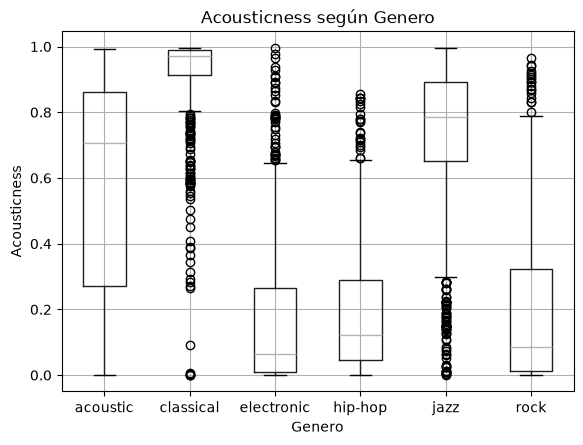

In [13]:
# Boxplot de Acousticness según Genero
df.boxplot(
    column="acousticness",
    by="Expected"
)

plt.title("Acousticness según Genero")
plt.suptitle("")
plt.xlabel("Genero")
plt.ylabel("Acousticness")
plt.show()

`acousticness` parece ser una de las variables más útiles para diferenciar géneros. `classical`, `jazz` y `acoustic` presentan valores generalmente altos, mientras que `electronic`, `hip-hop` y `rock` se concentran principalmente en valores bajos. Esto sugiere que puede ser una característica importante para la clasificación.

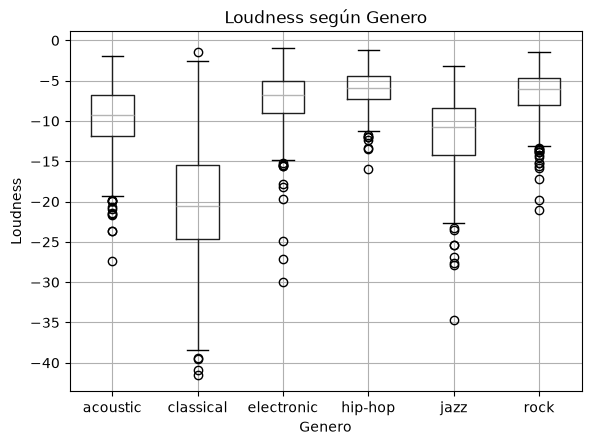

In [14]:
# Boxplot de Loudness según Genero
df.boxplot(
    column="loudness",
    by="Expected"
)

plt.title("Loudness según Genero")
plt.suptitle("")
plt.xlabel("Genero")
plt.ylabel("Loudness")
plt.show()

La variable `loudness` muestra diferencias importantes entre los géneros. `hip-hop`, `electronic` y `rock` tienden a presentar valores más altos, mientras que `classical` se concentra en valores considerablemente más bajos. Por lo tanto, puede ser una variable útil para diferenciar algunos géneros.


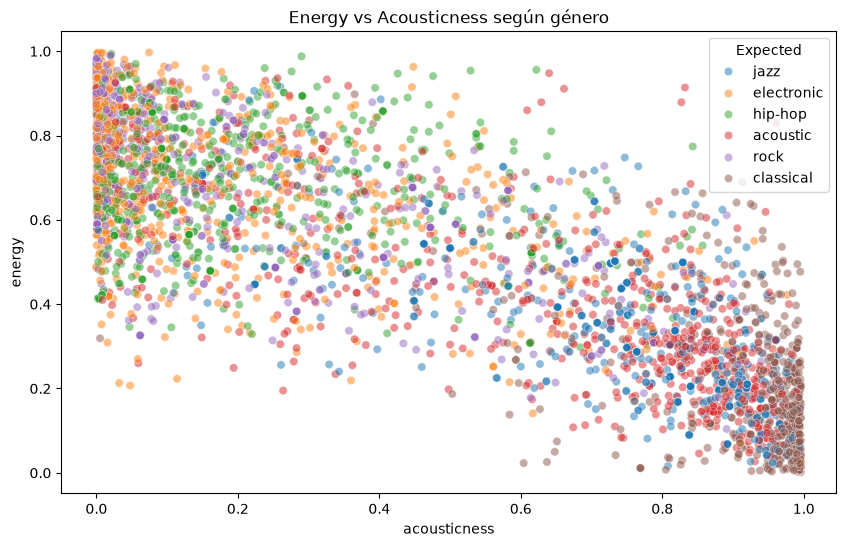

In [15]:
# Scatterplot de Energy vs Acousticness según género

import seaborn as sns
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="acousticness",
    y="energy",
    hue="Expected",
    alpha=0.5
)

plt.title("Energy vs Acousticness según género")
plt.show()

Se observa una relación inversa bastante clara entre `energy` y `acousticness`: las canciones más acústicas tienden a tener menor energía. Además, algunos géneros ocupan regiones distintas del gráfico, por ejemplo `classical` aparece principalmente con alta acousticness y baja energy, mientras que `hip-hop` y `electronic` suelen presentar mayor energy y menor acousticness.

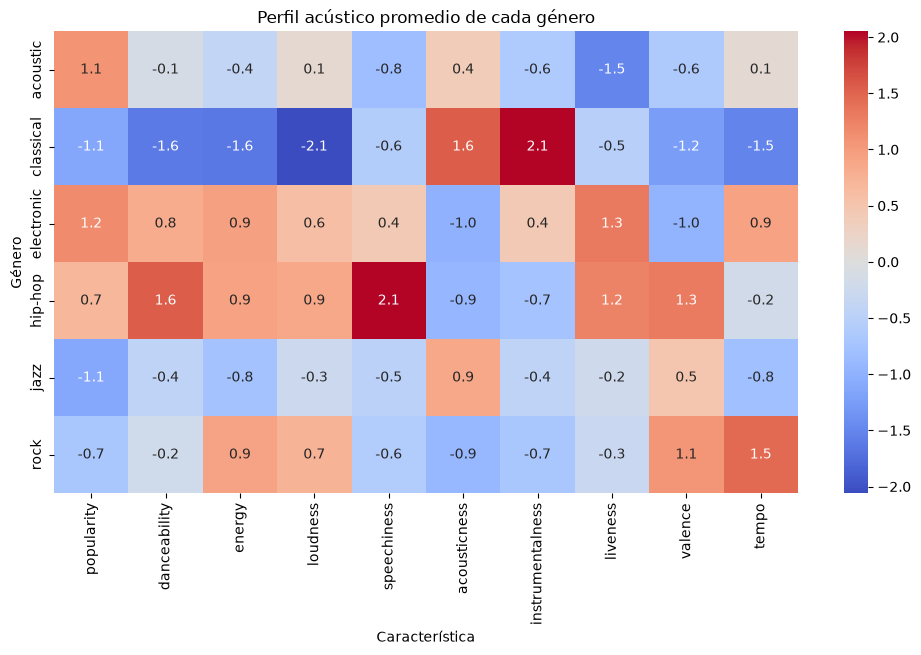

In [16]:
# Heatmap de características promedio por género
from sklearn.preprocessing import StandardScaler

features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

medias = df.groupby("Expected")[features].mean()

scaler = StandardScaler()
medias_scaled = pd.DataFrame(
    scaler.fit_transform(medias),
    index=medias.index,
    columns=medias.columns
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    medias_scaled,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".1f"
)

plt.title("Perfil acústico promedio de cada género")
plt.xlabel("Característica")
plt.ylabel("Género")
plt.show()

El heatmap permite observar que cada género presenta un perfil diferente. `classical` se destaca por su alta `acousticness` e `instrumentalness`, mientras que `hip-hop` presenta valores altos de `danceability`, `speechiness` y `valence`. `Electronic` y `rock` muestran mayor `energy` y `loudness`. 

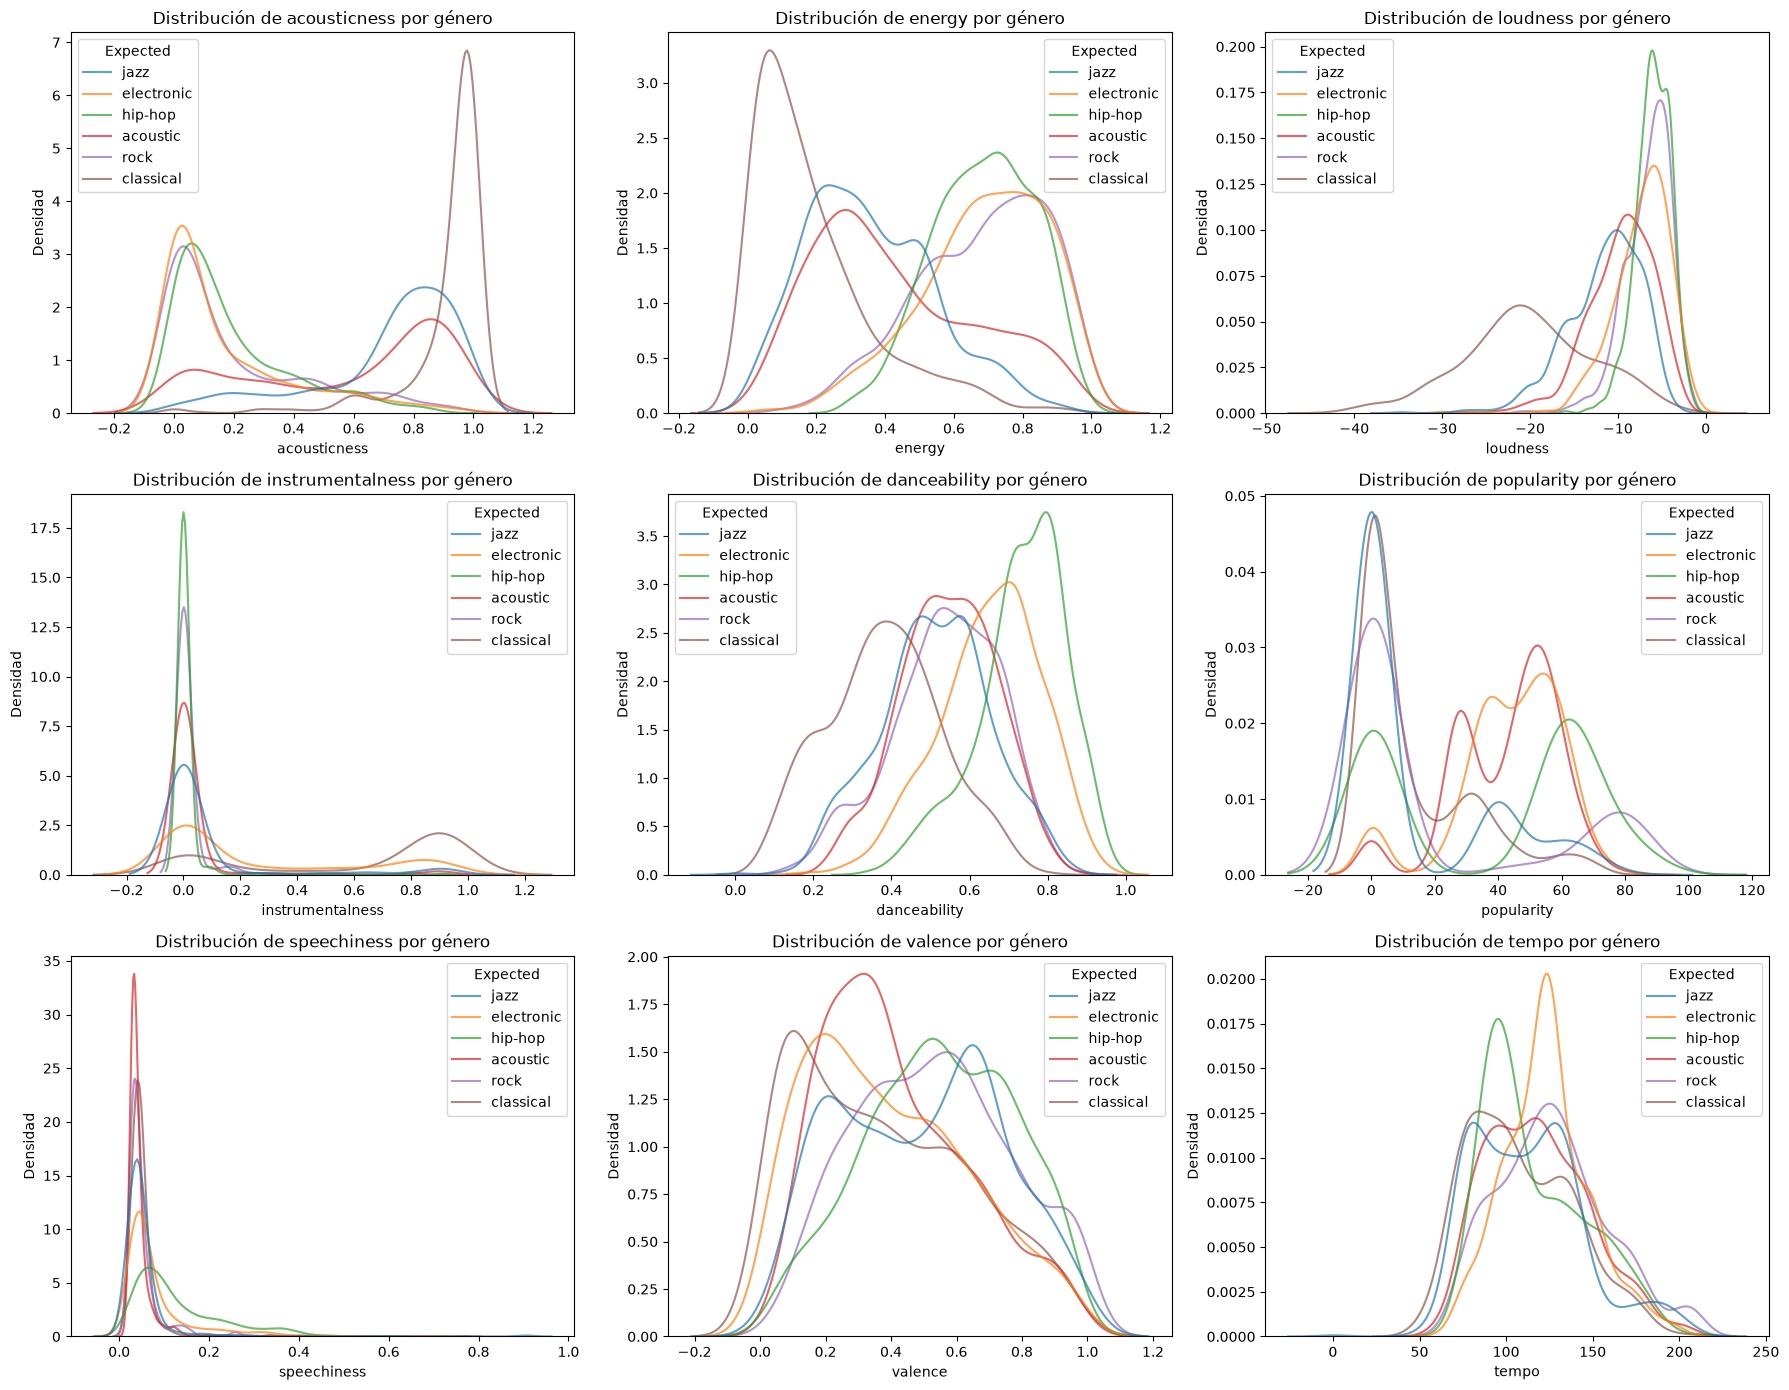

In [17]:
# Gráficos de distribución de variables por género
import matplotlib.pyplot as plt
import seaborn as sns

# Variables más importantes para diferenciar géneros
variables = [
    "acousticness",
    "energy",
    "loudness",
    "instrumentalness",
    "danceability",
    "popularity",
    "speechiness",
    "valence",
    "tempo"
]

# Crear grilla de gráficos
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

axes = axes.flatten()

# Una distribución por variable
for i, variable in enumerate(variables):
    
    sns.kdeplot(
        data=df,
        x=variable,
        hue="Expected",
        common_norm=False,
        fill=False,
        alpha=0.7,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribución de {variable} por género")
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

Las distribuciones muestran que algunas características separan mejor los géneros que otras. `acousticness`, `energy`, `loudness`, `danceability`, `instrumentalness` y `popularity` presentan diferencias visibles entre varias clases.

En cambio, variables como `valence` y `tempo` presentan una mayor superposición entre géneros, por lo que individualmente parecen tener menor capacidad para diferenciarlos.

En general, ninguna variable permite separar perfectamente todos los géneros por sí sola, por lo que será necesario combinar varias características para obtener una buena clasificación.

Como se lee este grafico? por ejemplo, la variable danceability presenta diferencias claras entre algunos géneros. Hip-hop y electronic muestran valores generalmente más altos, mientras que classical concentra valores más bajos. Sin embargo, jazz, acoustic y rock presentan distribuciones considerablemente superpuestas, por lo que esta característica por sí sola no permite diferenciar correctamente todos los géneros.

### 2. Preprocesamiento de los datos

#### Eliminación de columnas no informativas

La variable `Id` funciona únicamente como identificador de cada canción y no contiene información útil para predecir el género musical. La eliminamos.

#### Separación entre variables predictoras y variable objetivo

Separamos la variable objetivo `Expected` del resto de las características. De esta manera, utilizamos las variables acústicas como entrada del modelo (`X`) y el género musical como etiqueta a predecir (`y`).

#### Tratamiento de variables categóricas

Algunas variables, como `explicit`, `mode`, `key` o `time_signature`, representan información categórica o discreta.

En particular, `explicit` puede transformarse a una representación numérica binaria si fuera necesario. Otras variables como `key` y `time_signature` ya se encuentran codificadas numéricamente, aunque sus valores representan categorías y no necesariamente una relación numérica continua.

#### Escalado de variables numéricas

Las variables del dataset se encuentran en escalas muy diferentes. Por ejemplo, `tempo` puede tomar valores superiores a 100, mientras que variables como `energy`, `danceability` o `acousticness` se encuentran aproximadamente entre 0 y 1.

Por eso, utilizamos estandarización mediante `StandardScaler`. Esto transforma las variables para que tengan media cercana a 0 y desvío estándar cercano a 1.

#### Revisión de valores faltantes

Se verificó si existían valores nulos en el dataset. En caso de encontrarlos, sería necesario imputarlos o eliminar las filas correspondientes según la cantidad y la variable afectada.

#### Revisión de valores atípicos

Durante el EDA se observaron algunos valores extremos en variables como `loudness`, `speechiness` o `duration_ms`.

Sin embargo, no se eliminaron automáticamente, ya que estos valores pueden representar canciones reales con características poco frecuentes. Eliminar estos casos podría hacer que el modelo pierda información relevante.

#### División de los datos

El conjunto proporcionado para la competencia contiene dos archivos: `train.csv` y `test.csv`.

El archivo `train.csv` contiene las etiquetas correspondientes al género musical (`Expected`), por lo que se utiliza para entrenar y evaluar los modelos. En cambio, `test.csv` no contiene la variable objetivo y se utiliza únicamente para generar las predicciones finales que serán enviadas a Kaggle.

Para poder evaluar los modelos localmente, dividimos `train.csv` en un conjunto de entrenamiento del 80% y un conjunto de validación del 20%.

La división se realizó utilizando `stratify=y` para mantener la proporción de géneros en ambos conjuntos y `random_state=42` para garantizar la reproducibilidad.

Posteriormente, la búsqueda de hiperparámetros se realiza mediante validación cruzada sobre el conjunto de entrenamiento. Una vez seleccionado el mejor modelo, se puede volver a entrenar utilizando todos los datos disponibles de `train.csv` antes de generar las predicciones sobre `test.csv`.

### 3. Modelos de Machine Learning

Para establecer una primera comparación, entrenamos dos modelos de clasificación diferentes: **Logistic Regression** y **Random Forest**.

La elección de estos modelos permite comparar dos enfoques distintos. Logistic Regression construye una relación lineal entre las características de las canciones y las probabilidades de pertenecer a cada género, mientras que Random Forest utiliza múltiples árboles de decisión y puede capturar relaciones no lineales e interacciones más complejas entre las variables.

Para Logistic Regression utilizamos los datos previamente estandarizados, ya que este modelo es sensible a la escala de las variables.

En cambio, Random Forest no requiere escalado, por lo que se entrenó utilizando las variables en su escala original.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Variables predictoras y target
X = df.drop(columns=["Expected", "Id"])
y = df["Expected"]

# División estratificada
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



Buscamos el mejor escalador para el modelo de Regresion Logistica

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
def mejor_scaler(modelo):
    # Guardamos los escaladores, que vamos a usar para comparar
    scalers = {
        "StandardScaler": StandardScaler(),
        "MinMaxScaler": MinMaxScaler(),
        "RobustScaler": RobustScaler()
    }

    mejores_resultados = {"nombre": None, "instancia": None, "f1-score": -1}

    # 2. Hacemos un loop para evaluar cuál escalador obtiene el mejor desempeño 
    # comparamos los scalers utilizando únicamente el conjunto de validación. El conjunto de test se reserva exclusivamente para la evaluación final del modelo y así evitamos Data Leakage.
    for nombre, scaler in scalers.items():

        # Creamos un pipeline temporal para transformar los datos numéricos de train y validation

        pipe_temp = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scaler", scaler)
        ])

        # Seleccionamos las columnas numéricas para este test
        X_train_prueba = pipe_temp.fit_transform(X_train)
        X_val_prueba = pipe_temp.transform(X_valid)
        
        modelo.fit(X_train_prueba, y_train)
        
        # Evaluamos usando Accuracy
        y_pred = modelo.predict(X_val_prueba)
        score = f1_score(y_valid, y_pred, average="macro")
        
        if score > mejores_resultados["f1-score"]:
            mejores_resultados["f1-score"] = score
            mejores_resultados["nombre"] = nombre
            mejores_resultados["instancia"] = scaler

    print(f"El mejor escalador fue: {mejores_resultados['nombre']} (F1-Score: {mejores_resultados['f1-score']:.4f})")

    res = mejores_resultados["instancia"]
    return res


logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)
scaler = mejor_scaler(logistic_model)
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)


El mejor escalador fue: MinMaxScaler (F1-Score: 0.6743)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# Crear modelo
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Entrenar
logistic_model.fit(X_train_scaled, y_train)

# Predicciones sobre validación
y_pred_logistic = logistic_model.predict(X_valid_scaled)

# F1 Macro
f1_logistic = f1_score(
    y_valid,
    y_pred_logistic,
    average="macro"
)

print("F1 Macro - Logistic Regression:", f1_logistic)

print("\nClassification Report:")
print(classification_report(y_valid, y_pred_logistic))

F1 Macro - Logistic Regression: 0.6743276909961421

Classification Report:
              precision    recall  f1-score   support

    acoustic       0.61      0.55      0.58       140
   classical       0.91      0.81      0.86       140
  electronic       0.66      0.59      0.62       140
     hip-hop       0.66      0.74      0.70       140
        jazz       0.71      0.67      0.69       140
        rock       0.55      0.68      0.61       140

    accuracy                           0.67       840
   macro avg       0.68      0.67      0.67       840
weighted avg       0.68      0.67      0.67       840



Buscamos el mejor escalador para el modelo KNN

In [21]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)
scaler = mejor_scaler(knn_model)
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

El mejor escalador fue: MinMaxScaler (F1-Score: 0.7364)


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_valid_scaled)

f1_knn = f1_score(
    y_valid,
    y_pred_knn,
    average="macro"
)

print("F1 Macro - KNN:", f1_knn)

F1 Macro - KNN: 0.7364143861678961


In [23]:
from sklearn.ensemble import RandomForestClassifier

# Crear modelo
random_forest_model = RandomForestClassifier(
    random_state=42,
    max_depth=40,
    max_features=0.49951030827914167,
    min_samples_split= 2,
    n_estimators= 118
)

# Entrenar
random_forest_model.fit(X_train, y_train)

# Predicciones sobre validación
y_pred_rf = random_forest_model.predict(X_valid)

# F1 Macro
f1_rf = f1_score(
    y_valid,
    y_pred_rf,
    average="macro"
)

print("F1 Macro - Random Forest:", f1_rf)

print("\nClassification Report:")
print(classification_report(y_valid, y_pred_rf))

F1 Macro - Random Forest: 0.8364905535917564

Classification Report:
              precision    recall  f1-score   support

    acoustic       0.80      0.77      0.79       140
   classical       0.91      0.88      0.89       140
  electronic       0.79      0.86      0.83       140
     hip-hop       0.81      0.91      0.86       140
        jazz       0.88      0.75      0.81       140
        rock       0.84      0.85      0.85       140

    accuracy                           0.84       840
   macro avg       0.84      0.84      0.84       840
weighted avg       0.84      0.84      0.84       840



Busqueda de hiperparametros del Random Forest

In [24]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=22)

# COMPLETAR: el espacio de búsqueda, con Integer(...) para los enteros y Real(...) para max_features.
search_spaces = {
    'n_estimators': Integer(50, 300),
    'max_depth': Integer(5, 40),
    'min_samples_split': Integer(2,20),
    'max_features': Real(0.05, 0.5)
}

# COMPLETAR: definir la instancia de BayesSearchCV, con estimator = RandomForestClassifier(random_state = 22),
# y los otros hiperparámetros adecuados.
bs = BayesSearchCV(estimator=RandomForestClassifier(random_state=42), search_spaces=search_spaces, cv=cv, n_jobs=-1, verbose=2, n_iter=54, scoring='f1_macro')



In [25]:
%%time

bs.fit(X_train, y_train)

print(bs.best_score_)
print(bs.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


[CV] END max_depth=26, max_features=0.26549132491629146, min_samples_split=11, n_estimators=147; total time=   1.0s
[CV] END max_depth=26, max_features=0.26549132491629146, min_samples_split=11, n_estimators=147; total time=   1.2s
[CV] END max_depth=26, max_features=0.26549132491629146, min_samples_split=11, n_estimators=147; total time=   1.4s
[CV] END max_depth=26, max_features=0.26549132491629146, min_samples_split=11, n_estimators=147; total time=   1.4s
[CV] END max_depth=26, max_features=0.26549132491629146, min_samples_split=11, n_estimators=147; total time=   1.6s
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END max_depth=15, max_features=0.2834154416294226, min_samples_split=19, n_estimators=142; total time=   1.6s
[CV] END max_depth=15, max_features=0.2834154416294226, min_samples_split=19, n_estimators=142; total time=   1.6s
[CV] END max_depth=15, max_features=0.2834154416294226, min_samples_split=19, n_estimators=142; total time=   1.9s
[CV] END max_dep

In [26]:
import pandas as pd

resultados = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "KNN",
        "Random Forest"
    ],
    "F1 Macro": [
        f1_logistic,
        f1_knn,
        f1_rf
    ]
})

resultados.sort_values(
    "F1 Macro",
    ascending=False
)

,Modelo,F1 Macro
2,Random Forest,0.836491
1,KNN,0.736414
0,Logistic Regression,0.674328


### XGBoost

Además de Logistic Regression y Random Forest, se probó un modelo XGBoost, el cual permite modelar relaciones no lineales entre las variables.

Primero se entrenó un modelo base, utilizando los hiperparámetros por defecto, con el objetivo de obtener un nuevo punto de referencia antes de realizar la búsqueda de hiperparámetros.

In [27]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

# Codificamos las clases a números
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_valid_encoded = label_encoder.transform(y_valid)

# Modelo base
xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

# Entrenamiento
xgb_model.fit(X_train, y_train_encoded)

# Predicción
y_pred_xgb_encoded = xgb_model.predict(X_valid)

# Volvemos a los nombres originales de los géneros
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

# F1 Macro
f1_xgb = f1_score(
    y_valid,
    y_pred_xgb,
    average="macro"
)

print("F1 Macro - XGBoost:", f1_xgb)

F1 Macro - XGBoost: 0.847588469992684


El modelo XGBoost base obtuvo un **F1-Macro de 0.8476** sobre el conjunto de validación.

Este resultado fue superior al obtenido por Random Forest, cuyo F1-Macro fue aproximadamente 0.8351. Por lo tanto, XGBoost se convirtió en el modelo con mejor desempeño hasta este punto.

A partir de este resultado, se decidió realizar una búsqueda de hiperparámetros para intentar mejorar aún más su rendimiento.

#### Búsqueda de hiperparámetros de XGBoost

Para ajustar XGBoost se utilizó `RandomizedSearchCV`, explorando distintas combinaciones de hiperparámetros.

La búsqueda se realizó utilizando validación cruzada de 5 folds y optimizando `f1_macro`, que es la métrica oficial de la competencia.

In [28]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import uniform
import time
from sklearn.model_selection import ParameterSampler
import sklearn
import xgboost as xgb

param_dist_xgb = {'max_depth': list(range(1, 40)),
          'learning_rate': uniform(scale = 0.4),
          'gamma': uniform(scale = 2),
          'reg_lambda': uniform(scale = 5),        # Parámetro de regularización.
          'subsample': uniform(0.5, 0.5),          # Entre 0.5 y 1.
          'min_child_weight': uniform(scale = 5),
          'colsample_bytree': uniform(0.75, 0.25), # Entre 0.75 y 1.
          'n_estimators': list(range(1, 1000))
         }

random_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ),
    param_distributions=param_dist_xgb,
    n_iter=50,
    scoring="f1_macro",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_xgb.fit(X_train, y_train_encoded)

print("Mejores hiperparámetros:")
print(random_xgb.best_params_)

print("\nMejor F1 Macro promedio en CV:")
print(random_xgb.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejores hiperparámetros:
{'colsample_bytree': np.float64(0.8522382361035674), 'gamma': np.float64(0.34658864014169155), 'learning_rate': np.float64(0.06257481706843442), 'max_depth': 34, 'min_child_weight': np.float64(1.198936795787016), 'n_estimators': 118, 'reg_lambda': np.float64(3.5729796135003116), 'subsample': np.float64(0.8300986883588657)}

Mejor F1 Macro promedio en CV:
0.8241203832803361


In [58]:
best_xgb = random_xgb.best_estimator_

y_pred_xgb_tuned_encoded = best_xgb.predict(X_valid)

y_pred_xgb_tuned = label_encoder.inverse_transform(
    y_pred_xgb_tuned_encoded
)

f1_xgb_tuned = f1_score(
    y_valid,
    y_pred_xgb_tuned,
    average="macro"
)

print("F1 Macro - XGBoost tuned:", f1_xgb_tuned)

xgb_model_tuned = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **random_xgb.best_params_
)

F1 Macro - XGBoost tuned: 0.8510378057010914


In [30]:
print("Random Forest:", f1_rf)
print("XGBoost baseline:", f1_xgb)
print("XGBoost tuned:", f1_xgb_tuned)

Random Forest: 0.8364905535917564
XGBoost baseline: 0.847588469992684
XGBoost tuned: 0.8510378057010914


#### Resultado del ajuste de hiperparámetros

El modelo XGBoost base obtuvo un F1-Macro de **0.8476**, mientras que el modelo ajustado mediante `RandomizedSearchCV` obtuvo aproximadamente **0.851**.

Por lo tanto, la búsqueda de hiperparámetros si produjo una mejora sobre el conjunto de validación.

En consecuencia, hasta este punto se elige el **XGBoost tuned** como el modelo con mejor rendimiento, con un F1-Macro de 0.851.

popularity          0.216477
acousticness        0.141529
instrumentalness    0.111301
danceability        0.090907
loudness            0.086703
speechiness         0.075091
energy              0.067443
duration_ms         0.052851
valence             0.044227
tempo               0.034946
liveness            0.032738
key                 0.018975
explicit            0.011341
mode                0.010711
time_signature      0.004760
dtype: float64

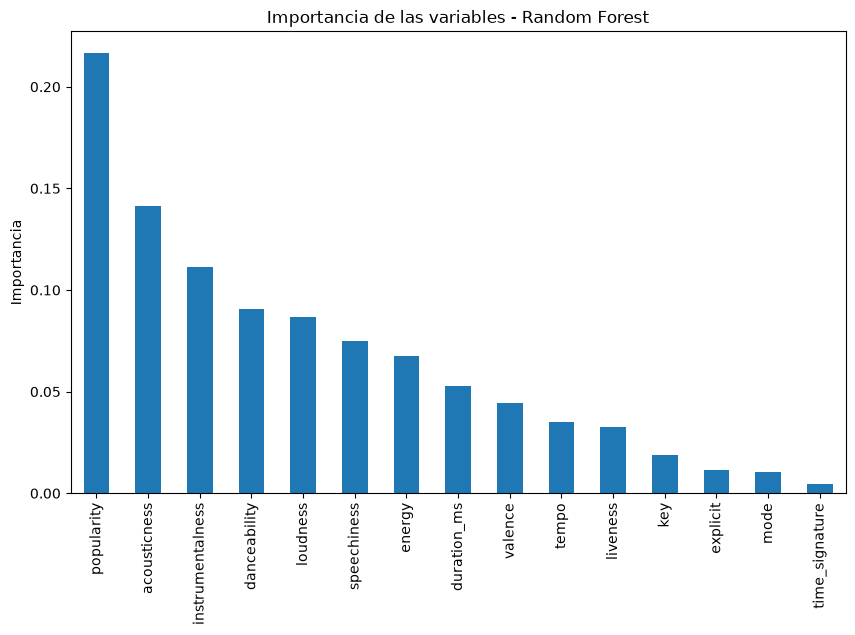

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(
    random_forest_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

display(importancias)

plt.figure(figsize=(10, 6))
importancias.plot(kind="bar")
plt.title("Importancia de las variables - Random Forest")
plt.ylabel("Importancia")
plt.show()

In [32]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_features = []

for n_features in range(5, len(importancias) + 1):

    features = importancias.head(n_features).index.tolist()

    modelo = XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    )

    scores = cross_val_score(
        modelo,
        X_train[features],
        y_train_encoded,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    resultados_features.append({
        "Cantidad de features": n_features,
        "F1 promedio": scores.mean(),
        "Desvío": scores.std()
    })

In [33]:
resultados_features = pd.DataFrame(resultados_features)

resultados_features.sort_values(
    "F1 promedio",
    ascending=False
)

,Cantidad de features,F1 promedio,Desvío
9,14,0.818500,0.003589
10,15,0.814962,0.005541
8,13,0.813628,0.006005
6,11,0.813400,0.006043
5,10,0.808000,0.008132
7,12,0.806885,0.007568
4,9,0.802811,0.007198
3,8,0.795968,0.009076
2,7,0.789364,0.009156
1,6,0.780114,0.005984


In [34]:
mejor_fila = resultados_features.loc[
    resultados_features["F1 promedio"].idxmax()
]

mejor_n = int(mejor_fila["Cantidad de features"])

features_seleccionadas = (
    importancias
    .head(mejor_n)
    .index
    .tolist()
)

print("Mejor cantidad de features:", mejor_n)
print("F1 Macro promedio:", mejor_fila["F1 promedio"])
print("Desvío:", mejor_fila["Desvío"])

print("\nFeatures seleccionadas:")
for feature in features_seleccionadas:
    print("-", feature)

'''
Mejor cantidad de features: 15
F1 Macro promedio: 0.8203805343433481
Desvío: 0.0076839909414719906

Features seleccionadas:
- popularity
- acousticness
- instrumentalness
- danceability
- loudness
- speechiness
- energy
- duration_ms
- valence
- tempo
- liveness
- key
- explicit
- mode
- time_signature
'''

Mejor cantidad de features: 14
F1 Macro promedio: 0.8185003828427899
Desvío: 0.003589471292977373

Features seleccionadas:
- popularity
- acousticness
- instrumentalness
- danceability
- loudness
- speechiness
- energy
- duration_ms
- valence
- tempo
- liveness
- key
- explicit
- mode


'\nMejor cantidad de features: 15\nF1 Macro promedio: 0.8203805343433481\nDesvío: 0.0076839909414719906\n\nFeatures seleccionadas:\n- popularity\n- acousticness\n- instrumentalness\n- danceability\n- loudness\n- speechiness\n- energy\n- duration_ms\n- valence\n- tempo\n- liveness\n- key\n- explicit\n- mode\n- time_signature\n'

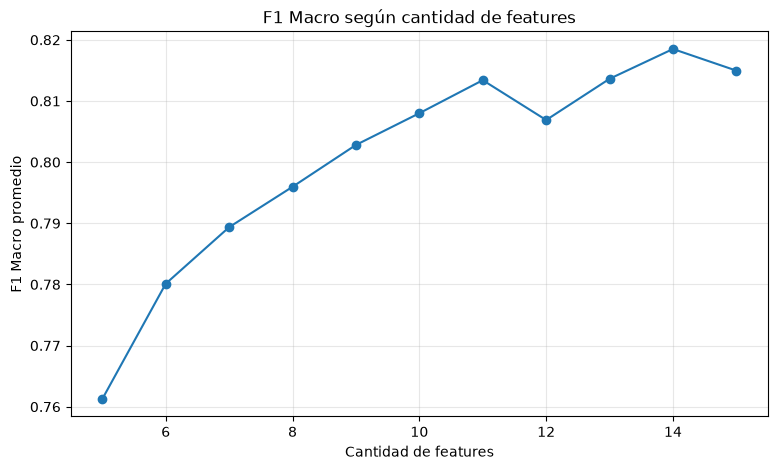

In [35]:
plt.figure(figsize=(9, 5))

plt.plot(
    resultados_features["Cantidad de features"],
    resultados_features["F1 promedio"],
    marker="o"
)

plt.xlabel("Cantidad de features")
plt.ylabel("F1 Macro promedio")
plt.title("F1 Macro según cantidad de features")
plt.grid(alpha=0.3)

plt.show()

Hacemos una optimizacion de hiperparametros con los features seleccionados

In [36]:
random_xgb_new = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ),
    param_distributions=param_dist_xgb,
    n_iter=50,
    scoring="f1_macro",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_xgb_new.fit(X_train[features_seleccionadas], y_train_encoded)

print("Mejores hiperparámetros:")
print(random_xgb_new.best_params_)

print("\nMejor F1 Macro promedio en CV:")
print(random_xgb_new.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejores hiperparámetros:
{'colsample_bytree': np.float64(0.8522382361035674), 'gamma': np.float64(0.34658864014169155), 'learning_rate': np.float64(0.06257481706843442), 'max_depth': 34, 'min_child_weight': np.float64(1.198936795787016), 'n_estimators': 118, 'reg_lambda': np.float64(3.5729796135003116), 'subsample': np.float64(0.8300986883588657)}

Mejor F1 Macro promedio en CV:
0.8212030729029134


In [ ]:
# Modelo A: Todas las columnas (15) + Hiperparámetros de la primera búsqueda
modelo_A = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **random_xgb.best_params_
)

# Modelo B: Columnas filtradas (14) + Hiperparámetros de la nueva búsqueda
modelo_B = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **random_xgb_new.best_params_
)

# Evaluamos ambos modelos bajo las mismas exactas condiciones
scores_A = cross_val_score(modelo_A, X_train, y_train_encoded, cv=cv, scoring="f1_macro", n_jobs=-1)
scores_B = cross_val_score(modelo_B, X_train[features_seleccionadas], y_train_encoded, cv=cv, scoring="f1_macro", n_jobs=-1)


print(f"Modelo A (15 vars): {scores_A.mean():.5f} (+/- {scores_A.std():.5f})")
print(f"Modelo B (14 vars): {scores_B.mean():.5f} (+/- {scores_B.std():.5f})")


🏆 RESULTADOS DEL DUELO FINAL 🏆
Modelo A (15 vars): 0.82023 (+/- 0.01090)
Modelo B (14 vars): 0.81874 (+/- 0.00639)


#### Conclusión del Feature Selection

El análisis de selección de características demostró que reducir el espacio de 15 a 14 variables conserva un rendimiento competitivo, pasando de un F1-Macro de 0.8202 a 0.8187 y logrando una mayor estabilidad en la validación cruzada ($\pm 0.00639$ frente a $\pm 0.01090$). Sin embargo, priorizando el objetivo directo de la competencia en Kaggle, optamos por conservar el modelo completo de 15 variables. Esta decisión permite maximizar cada décima en la métrica principal (F1-Macro) aprovechando toda la información acústica disponible. No obstante, reconocemos que el subconjunto de 14 características representa una alternativa óptima bajo el principio de parsimonia para un entorno de producción real, al ofrecer un sistema más simple y con menor varianza.

In [53]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [54]:
from sklearn.model_selection import cross_val_score

scores_logistic = cross_val_score(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("Logistic Regression")
print("F1 por fold:", scores_logistic)
print("F1 promedio:", scores_logistic.mean())
print("Desvío:", scores_logistic.std())

Logistic Regression
F1 por fold: [0.65583802 0.60497518 0.66069505 0.6453441  0.67908088]
F1 promedio: 0.6491866460767712
Desvío: 0.02465671829554278


In [55]:
scores_rf = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("Random Forest")
print("F1 por fold:", scores_rf)
print("F1 promedio:", scores_rf.mean())
print("Desvío:", scores_rf.std())

Random Forest
F1 por fold: [0.80657109 0.79557095 0.80864061 0.82459967 0.83430277]
F1 promedio: 0.813937017767292
Desvío: 0.013770091454447082


In [59]:
scores_xgb = cross_val_score(
    xgb_model_tuned,
    X_train,
    y_train_encoded,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("XGBoost")
print("F1 por fold:", scores_xgb)
print("F1 promedio:", scores_xgb.mean())
print("Desvío:", scores_xgb.std())

XGBoost
F1 por fold: [0.81372279 0.80234729 0.83311411 0.82553134 0.82641461]
F1 promedio: 0.8202260278645669
Desvío: 0.010904024560865375


In [60]:
resultados_model_selection = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "F1 Macro promedio": [
        scores_logistic.mean(),
        scores_rf.mean(),
        scores_xgb.mean()
    ],
    "Desvío": [
        scores_logistic.std(),
        scores_rf.std(),
        scores_xgb.std()
    ]
})

resultados_model_selection.sort_values(
    "F1 Macro promedio",
    ascending=False
)

,Modelo,F1 Macro promedio,Desvío
2,XGBoost,0.820226,0.010904
1,Random Forest,0.813937,0.013770
0,Logistic Regression,0.649187,0.024657


#### Conclusión del Model Selection

A partir de la validación cruzada estratificada de 5 folds, XGBoost obtuvo el mejor rendimiento promedio, con un **F1-Macro de 0.820** y un desvío estándar de aproximadamente **0.0109**.

Random Forest obtuvo un F1-Macro promedio de **0.8139**, mientras que Logistic Regression presentó un rendimiento considerablemente menor, con un promedio de **0.01377**.

Además de obtener el mejor F1-Macro promedio, XGBoost presentó el menor desvío entre folds, lo que indica un comportamiento más estable frente a distintas particiones de los datos.

Por este motivo, XGBoost fue seleccionado como el modelo final para continuar con las siguientes etapas del trabajo.

In [61]:
scores_xgb_todas = cross_val_score(
    xgb_model_tuned,
    X_train,
    y_train_encoded,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("XGBoost todas las features")
print("F1 promedio:", scores_xgb_todas.mean())
print("Desvío:", scores_xgb_todas.std())

XGBoost todas las features
F1 promedio: 0.8202260278645669
Desvío: 0.010904024560865375


In [44]:
print("XGBoost 14 features:", scores_xgb.mean())
print("XGBoost todas las features:", scores_xgb_todas.mean())

XGBoost 14 features: 0.8185003828427899
XGBoost todas las features: 0.8153210045897505


In [66]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# =========================================================
# 1. PREPARAR TRAIN COMPLETO
# =========================================================

X_full = df.drop(columns=["Expected", "Id"])
y_full = df["Expected"]


# Codificamos los géneros
label_encoder_final = LabelEncoder()
y_full_encoded = label_encoder_final.fit_transform(y_full)

# =========================================================
# 2. ENTRENAR MODELO FINAL
# =========================================================

xgb_final = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **random_xgb.best_params_
)
xgb_final.fit(
    X_full,
    y_full_encoded
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,np.float64(0.8522382361035674)
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_

In [67]:
# =========================================================
# 3. PREPARAR TEST DE KAGGLE
# =========================================================

test_kaggle = pd.read_csv("test.csv")

X_test_kaggle = test_kaggle.drop(columns=["Id"])


In [68]:
# =========================================================
# 4. PREDECIR TEST.CSV
# =========================================================

pred_encoded = xgb_final.predict(
    X_test_kaggle
)

pred_generos = label_encoder_final.inverse_transform(
    pred_encoded
)

In [69]:
# =========================================================
# 5. CREAR SUBMISSION
# =========================================================

submission = pd.DataFrame({
    "Id": test_kaggle["Id"],
    "Expected": pred_generos
})

submission.to_csv(
    "submission_xgboost_tuned2.csv",
    index=False
)

submission.head()

,Id,Expected
0,3793,acoustic
1,5701,acoustic
2,2721,electronic
3,4079,hip-hop
4,479,electronic


In [49]:
xgb_all = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb_all.fit(
    X_full,
    y_full_encoded
)

pred_all_encoded = xgb_all.predict(
    test_kaggle.drop(columns=["Id"])
)

pred_all = label_encoder_final.inverse_transform(
    pred_all_encoded
)

submission_all = pd.DataFrame({
    "Id": test_kaggle["Id"],
    "Expected": pred_all
})

submission_all.to_csv(
    "submission_xgb_all_features.csv",
    index=False
)

#### Resultados en Kaggle

Se realizaron dos submissions con XGBoost:

- **XGBoost con 14 features seleccionadas:** F1 público de **0.82759**.
- **XGBoost con todas las variables:** F1 público de **0.82803**.

La diferencia entre ambos resultados es muy pequeña, aunque la versión con todas las variables obtuvo un rendimiento levemente superior en el leaderboard público de Kaggle.

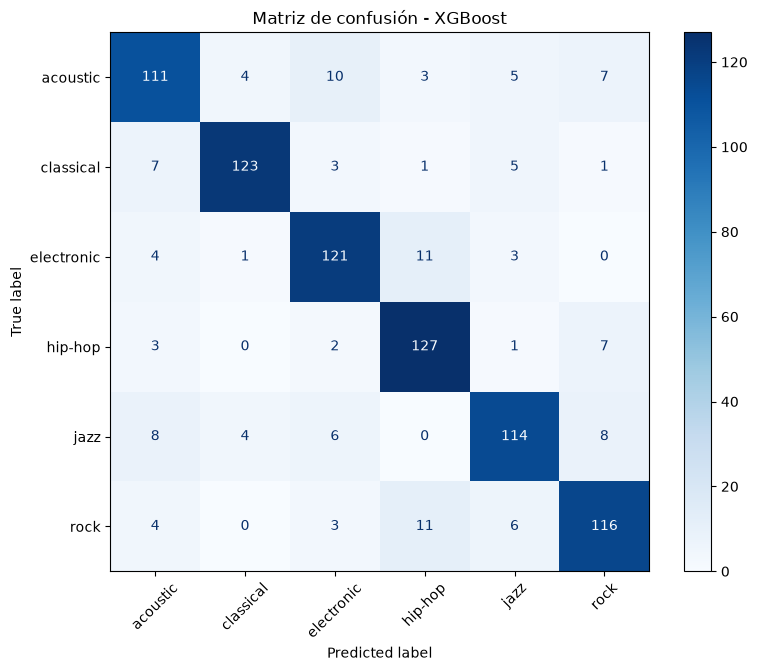

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predicciones del XGBoost base sobre validación
y_pred_xgb_encoded = xgb_model.predict(X_valid)

y_pred_xgb = label_encoder.inverse_transform(
    y_pred_xgb_encoded
)

cm = confusion_matrix(
    y_valid,
    y_pred_xgb,
    labels=label_encoder.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Matriz de confusión - XGBoost")
plt.show()

In [51]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_valid,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

    acoustic       0.81      0.79      0.80       140
   classical       0.93      0.88      0.90       140
  electronic       0.83      0.86      0.85       140
     hip-hop       0.83      0.91      0.87       140
        jazz       0.85      0.81      0.83       140
        rock       0.83      0.83      0.83       140

    accuracy                           0.85       840
   macro avg       0.85      0.85      0.85       840
weighted avg       0.85      0.85      0.85       840



In [52]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid_xgb = {
    "n_estimators": [80, 100, 120, 150],
    "max_depth": [4, 5, 6, 7],
    "learning_rate": [0.2, 0.3, 0.4],
    "subsample": [0.9, 1.0],
    "colsample_bytree": [0.9, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ),
    param_grid=param_grid_xgb,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(
    X_train,
    y_train_encoded
)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


KeyboardInterrupt: 

In [ ]:
print("Mejores parámetros:")
print(grid_xgb.best_params_)

print("\nMejor F1 Macro promedio en CV:")
print(grid_xgb.best_score_)

Mejores parámetros:
{'colsample_bytree': 0.9, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 80, 'subsample': 0.9}

Mejor F1 Macro promedio en CV:
0.8271799981523353


In [ ]:
best_xgb_grid = grid_xgb.best_estimator_

y_pred_grid_encoded = best_xgb_grid.predict(X_valid)

y_pred_grid = label_encoder.inverse_transform(
    y_pred_grid_encoded
)

f1_xgb_grid = f1_score(
    y_valid,
    y_pred_grid,
    average="macro"
)

print("XGBoost base:", f1_xgb)
print("XGBoost tuning fino:", f1_xgb_grid)

XGBoost base: 0.847588469992684
XGBoost tuning fino: 0.8521748816174837


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier

voting_model = VotingClassifier(
    estimators=[
        (
            "rf",
            RandomForestClassifier(
                random_state=42
            )
        ),
        (
            "xgb",
            best_xgb_grid
        )
    ],
    voting="soft"
)

In [ ]:
voting_model.fit(
    X_train,
    y_train
)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[object](6,)","['acoustic','classical','electronic','hip-hop','jazz','rock']"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[RandomForestC...ndom_state=42), XGBClassifier...ree=None, ...)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U16](15,)","['popularity','duration_ms','explicit',...,'valence','tempo', 'time_signature']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [ ]:
y_pred_voting = voting_model.predict(
    X_valid
)

f1_voting = f1_score(
    y_valid,
    y_pred_voting,
    average="macro"
)

print("XGBoost tuning fino:", f1_xgb_grid)
print("Voting RF + XGBoost:", f1_voting)

XGBoost tuning fino: 0.8521748816174837
Voting RF + XGBoost: 0.8558397142984235


#### Ensamble de modelos

Se combinó Random Forest con el mejor modelo XGBoost mediante un `VotingClassifier`.

Se utilizó **soft voting**, que combina las probabilidades estimadas por ambos modelos para realizar la predicción final.

El objetivo fue aprovechar que ambos modelos pueden cometer errores diferentes y evaluar si la combinación permite mejorar el F1-Macro respecto de XGBoost por separado.

In [ ]:
# Datos completos
X_full = df.drop(columns=["Expected", "Id"])
y_full = df["Expected"]

# Reentrenamos el ensemble con todo el train
voting_final = VotingClassifier(
    estimators=[
        (
            "rf",
            RandomForestClassifier(
                random_state=42
            )
        ),
        (
            "xgb",
            best_xgb_grid
        )
    ],
    voting="soft"
)

voting_final.fit(
    X_full,
    y_full
)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[object](6,)","['acoustic','classical','electronic','hip-hop','jazz','rock']"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[RandomForestC...ndom_state=42), XGBClassifier...ree=None, ...)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U16](15,)","['popularity','duration_ms','explicit',...,'valence','tempo', 'time_signature']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [ ]:
test_kaggle = pd.read_csv("test.csv")

X_test_kaggle = test_kaggle.drop(columns=["Id"])

pred_voting = voting_final.predict(
    X_test_kaggle
)

submission_voting = pd.DataFrame({
    "Id": test_kaggle["Id"],
    "Expected": pred_voting
})

submission_voting.to_csv(
    "submission_voting_rf_xgb.csv",
    index=False
)

submission_voting.head()

print(submission_voting.shape)
print(submission_voting.isnull().sum())
print(submission_voting["Expected"].value_counts())

(1800, 2)
Id          0
Expected    0
dtype: int64
Expected
acoustic      325
hip-hop       314
rock          311
classical     295
electronic    288
jazz          267
Name: count, dtype: int64


In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# =========================================================
# 1. PREPARAR TRAIN COMPLETO
# =========================================================

X_full = df.drop(columns=["Expected", "Id"])
y_full = df["Expected"]

# Codificar géneros
label_encoder_final = LabelEncoder()
y_full_encoded = label_encoder_final.fit_transform(y_full)

# =========================================================
# 2. CREAR XGBOOST CON LOS MEJORES HIPERPARÁMETROS
# =========================================================

xgb_tuned_final = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **grid_xgb.best_params_
)

# Entrenar usando TODO train.csv
xgb_tuned_final.fit(
    X_full,
    y_full_encoded
)

# =========================================================
# 3. CARGAR TEST DE KAGGLE
# =========================================================

test_kaggle = pd.read_csv("test.csv")

X_test_kaggle = test_kaggle.drop(columns=["Id"])

# =========================================================
# 4. GENERAR PREDICCIONES
# =========================================================

pred_tuned_encoded = xgb_tuned_final.predict(
    X_test_kaggle
)

pred_tuned = label_encoder_final.inverse_transform(
    pred_tuned_encoded
)

# =========================================================
# 5. CREAR SUBMISSION
# =========================================================

submission_tuned = pd.DataFrame({
    "Id": test_kaggle["Id"],
    "Expected": pred_tuned
})

submission_tuned.to_csv(
    "submission_xgboost_tuned.csv",
    index=False
)

# =========================================================
# 6. VERIFICAR
# =========================================================

print("Mejores hiperparámetros:")
print(grid_xgb.best_params_)

print("\nShape submission:")
print(submission_tuned.shape)

print("\nValores nulos:")
print(submission_tuned.isnull().sum())

print("\nDistribución de predicciones:")
print(submission_tuned["Expected"].value_counts())

display(submission_tuned.head())

Mejores hiperparámetros:
{'colsample_bytree': 0.9, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 80, 'subsample': 0.9}

Shape submission:
(1800, 2)

Valores nulos:
Id          0
Expected    0
dtype: int64

Distribución de predicciones:
Expected
acoustic      320
rock          315
hip-hop       310
classical     295
electronic    280
jazz          280
Name: count, dtype: int64


,Id,Expected
0,3793,acoustic
1,5701,acoustic
2,2721,electronic
3,4079,hip-hop
4,479,electronic


In [ ]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import pandas as pd

# =========================================================
# 1. USAMOS TODO TRAIN.CSV
# =========================================================

X_cv = df.drop(columns=["Expected", "Id"])
y_cv = df["Expected"]

label_encoder_cv = LabelEncoder()
y_cv_encoded = label_encoder_cv.fit_transform(y_cv)

# =========================================================
# 2. CROSS-VALIDATION ESTRATIFICADA
# =========================================================

cv_final = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================================================
# 3. ESPACIO DE HIPERPARÁMETROS
# =========================================================

param_dist = {
    "n_estimators": [80, 100, 120, 150, 200, 250, 300],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.03, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 5],
    "gamma": [0, 0.05, 0.1, 0.2],
    "reg_alpha": [0, 0.01, 0.05, 0.1],
    "reg_lambda": [0.5, 1, 2, 5]
}

# =========================================================
# 4. RANDOMIZED SEARCH SOBRE TODO EL TRAIN
# =========================================================

search_xgb_cv = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=60,
    scoring="f1_macro",
    cv=cv_final,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_xgb_cv.fit(
    X_cv,
    y_cv_encoded
)

# =========================================================
# 5. RESULTADOS
# =========================================================

print("Mejor F1 Macro promedio CV:")
print(search_xgb_cv.best_score_)

print("\nMejores hiperparámetros:")
print(search_xgb_cv.best_params_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Mejor F1 Macro promedio CV:
0.8373388120506553

Mejores hiperparámetros:
{'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.05, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.08, 'gamma': 0.1, 'colsample_bytree': 0.8}


In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# =========================================================
# 1. PREPARAR TODO EL TRAIN
# =========================================================

X_full = df.drop(columns=["Expected", "Id"])
y_full = df["Expected"]

label_encoder_final = LabelEncoder()
y_full_encoded = label_encoder_final.fit_transform(y_full)

# =========================================================
# 2. USAR LOS MEJORES HIPERPARÁMETROS ENCONTRADOS POR CV
# =========================================================

xgb_cv_final = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    **search_xgb_cv.best_params_
)

xgb_cv_final.fit(
    X_full,
    y_full_encoded
)

# =========================================================
# 3. CARGAR TEST
# =========================================================

test_kaggle = pd.read_csv("test.csv")

X_test_kaggle = test_kaggle.drop(columns=["Id"])

# =========================================================
# 4. PREDECIR
# =========================================================

pred_cv_encoded = xgb_cv_final.predict(
    X_test_kaggle
)

pred_cv = label_encoder_final.inverse_transform(
    pred_cv_encoded
)

# =========================================================
# 5. CREAR SUBMISSION
# =========================================================

submission_cv = pd.DataFrame({
    "Id": test_kaggle["Id"],
    "Expected": pred_cv
})

submission_cv.to_csv(
    "submission_xgboost_cv.csv",
    index=False
)

print("Mejor CV F1 Macro:", search_xgb_cv.best_score_)
print("Mejores parámetros:", search_xgb_cv.best_params_)
print("Shape:", submission_cv.shape)
print("Nulos:")
print(submission_cv.isnull().sum())

display(submission_cv.head())

Mejor CV F1 Macro: 0.8373388120506553
Mejores parámetros: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.05, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.08, 'gamma': 0.1, 'colsample_bytree': 0.8}
Shape: (1800, 2)
Nulos:
Id          0
Expected    0
dtype: int64


,Id,Expected
0,3793,acoustic
1,5701,acoustic
2,2721,electronic
3,4079,hip-hop
4,479,electronic
